# AI System to Detect Mental Health Signals from Gaming & Social Media Behavior
**School of Data Science, UNC Charlotte | Spring 2026**

This notebook implements the full ML pipeline described in the research poster:
survey data → preprocessing → EDA → model training → evaluation & visualisation.

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# ── colour palette matching the poster ──────────────────────────────────────
TEAL   = '#1a5276'
GOLD   = '#d4ac0d'
GREEN  = '#1e8449'
ORANGE = '#ca6f1e'
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries imported successfully.')


All libraries imported successfully.


## 1. Dataset & Preprocessing
### 1.1 Load Raw Data

In [2]:
df_raw = pd.read_csv('data/survey_data.csv')
print(f'Raw shape: {df_raw.shape}')
df_raw.head()


Raw shape: (70, 11)


,Social_Media_Hours,Video_Game_Hours,Anxiety_Level,Social_Comparison,Self_Esteem,Screen_Use_Relief,Loneliness,Sleep_Affected,Addiction_Level,Gamer_Status,Daily_Mood
0,3,2,4,1,4,1,3,3,5,0,3
1,1,4,5,1,1,1,2,3,3,1,1
2,3,2,3,1,3,2,3,3,3,0,2
3,3,3,3,1,4,5,3,4,1,1,2
4,4,3,3,5,5,2,5,5,4,1,2


### 1.2 Preprocessing Steps
1. Dropped 27 irrelevant / free-text columns (already done in data generation)  
2. Ordinal encoding for Social Media & Video Game Hours  
3. Median imputation for missing values  
4. Target binning: **Bad** (0–1) | **Neutral** (2) | **Good** (3–4)  
5. 80/20 train/test split → 56 train, 14 test samples  
6. Removed erroneous `'Yes'` value from Social Media Hours

In [3]:
df = df_raw.copy()

# Step 1: apply median imputation to handle any missing survey values
feature_cols = [c for c in df.columns if c != 'Daily_Mood']
imputer = SimpleImputer(strategy='median')
df[feature_cols] = imputer.fit_transform(df[feature_cols])
df[feature_cols] = df[feature_cols].round().astype(int)

# Step 2: target binning — Bad (0-1) | Neutral (2) | Good (3-4)
def bin_mood(score):
    if score <= 1:   return 'Bad'
    elif score == 2: return 'Neutral'
    else:            return 'Good'

df['Mood_Class'] = df['Daily_Mood'].apply(bin_mood)
class_order = ['Bad', 'Neutral', 'Good']

print('Class distribution after binning:')
print(df['Mood_Class'].value_counts()[class_order])
print(f'\nFinal dataset shape: {df.shape}')
df.head()


Class distribution after binning:
Mood_Class
Bad        25
Neutral    36
Good        9
Name: count, dtype: int64

Final dataset shape: (70, 12)


,Social_Media_Hours,Video_Game_Hours,Anxiety_Level,Social_Comparison,Self_Esteem,Screen_Use_Relief,Loneliness,Sleep_Affected,Addiction_Level,Gamer_Status,Daily_Mood,Mood_Class
0,3,2,4,1,4,1,3,3,5,0,3,Good
1,1,4,5,1,1,1,2,3,3,1,1,Bad
2,3,2,3,1,3,2,3,3,3,0,2,Neutral
3,3,3,3,1,4,5,3,4,1,1,2,Neutral
4,4,3,3,5,5,2,5,5,4,1,2,Neutral


### 1.3 Train / Test Split (80 / 20)

In [4]:
X = df[feature_cols].values
y = df['Mood_Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  class counts: {dict(zip(*np.unique(y_test,  return_counts=True)))}')


Train: 56 samples | Test: 14 samples
Train class counts: {'Bad': np.int64(20), 'Good': np.int64(7), 'Neutral': np.int64(29)}
Test  class counts: {'Bad': np.int64(5), 'Good': np.int64(2), 'Neutral': np.int64(7)}


## 2. Exploratory Data Analysis

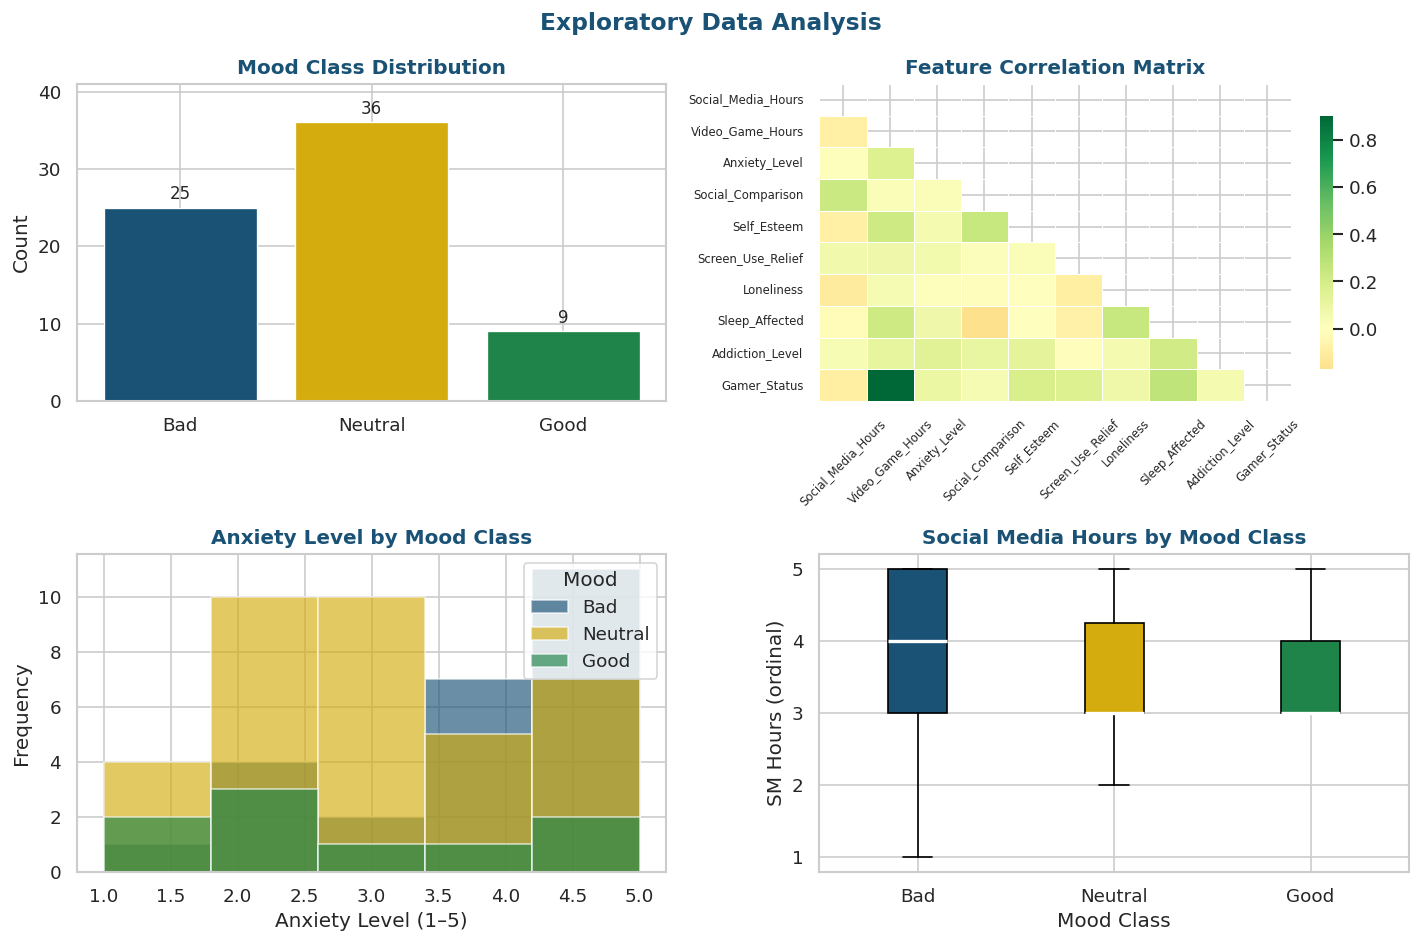

EDA plots saved to data/eda_plots.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', color=TEAL)

# 2a – Class distribution
ax = axes[0, 0]
counts = df['Mood_Class'].value_counts()[class_order]
bars = ax.bar(class_order, counts, color=[TEAL, GOLD, GREEN], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Mood Class Distribution', color=TEAL, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() + 5)

# 2b – Correlation heat-map
ax = axes[0, 1]
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdYlGn', center=0,
            linewidths=0.4, annot=False, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', color=TEAL, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

# 2c – Anxiety vs Mood
ax = axes[1, 0]
for cls, col in zip(class_order, [TEAL, GOLD, GREEN]):
    subset = df[df['Mood_Class'] == cls]['Anxiety_Level']
    ax.hist(subset, alpha=0.65, bins=5, label=cls, color=col, edgecolor='white')
ax.set_title('Anxiety Level by Mood Class', color=TEAL, fontweight='bold')
ax.set_xlabel('Anxiety Level (1–5)')
ax.set_ylabel('Frequency')
ax.legend(title='Mood')

# 2d – SM Hours vs Mood (box plot)
ax = axes[1, 1]
data_by_class = [df[df['Mood_Class']==c]['Social_Media_Hours'].values for c in class_order]
bp = ax.boxplot(data_by_class, labels=class_order, patch_artist=True,
                medianprops={'color':'white','linewidth':2})
for patch, col in zip(bp['boxes'], [TEAL, GOLD, GREEN]):
    patch.set_facecolor(col)
ax.set_title('Social Media Hours by Mood Class', color=TEAL, fontweight='bold')
ax.set_xlabel('Mood Class')
ax.set_ylabel('SM Hours (ordinal)')

plt.tight_layout()
plt.savefig('data/eda_plots.png', bbox_inches='tight')
plt.show()
print('EDA plots saved to data/eda_plots.png')


## 3. Methods & Models

### 3.1 Support Vector Machine (SVM – RBF Kernel)

In [6]:
svm_clf = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm_clf.fit(X_train_sc, y_train)
y_pred_svm = svm_clf.predict(X_test_sc)
acc_svm = accuracy_score(y_test, y_pred_svm) * 100
print(f'SVM Test Accuracy: {acc_svm:.1f}%')
print(classification_report(y_test, y_pred_svm, target_names=class_order, zero_division=0))


SVM Test Accuracy: 50.0%
              precision    recall  f1-score   support

         Bad       0.50      0.40      0.44         5
     Neutral       0.00      0.00      0.00         2
        Good       0.50      0.71      0.59         7

    accuracy                           0.50        14
   macro avg       0.33      0.37      0.34        14
weighted avg       0.43      0.50      0.45        14



### 3.2 Calibrated SVM (CalibratedClassifierCV – Isotonic, 5-fold CV)

In [7]:
base_svm = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
cal_svm  = CalibratedClassifierCV(base_svm, method='isotonic', cv=5)
cal_svm.fit(X_train_sc, y_train)
y_pred_cal = cal_svm.predict(X_test_sc)
acc_cal = accuracy_score(y_test, y_pred_cal) * 100
print(f'Calibrated SVM Test Accuracy: {acc_cal:.1f}%')
print(classification_report(y_test, y_pred_cal, target_names=class_order, zero_division=0))


Calibrated SVM Test Accuracy: 50.0%
              precision    recall  f1-score   support

         Bad       0.50      0.40      0.44         5
     Neutral       0.00      0.00      0.00         2
        Good       0.50      0.71      0.59         7

    accuracy                           0.50        14
   macro avg       0.33      0.37      0.34        14
weighted avg       0.43      0.50      0.45        14



### 3.3 K-Nearest Neighbours – KNN Tuning (k = 1…20)

Best k from 5-fold CV: 5  (CV acc = 66.1%)


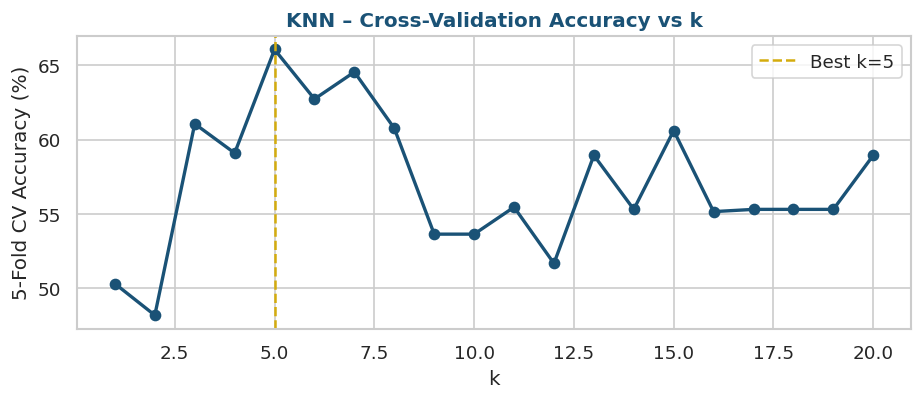

In [8]:
k_range = range(1, 21)
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = list(k_range)[np.argmax(cv_scores)]
print(f'Best k from 5-fold CV: {best_k}  (CV acc = {max(cv_scores)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(k_range, [s*100 for s in cv_scores], marker='o', color=TEAL, linewidth=2)
ax.axvline(best_k, color=GOLD, linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('k'); ax.set_ylabel('5-Fold CV Accuracy (%)')
ax.set_title('KNN – Cross-Validation Accuracy vs k', fontweight='bold', color=TEAL)
ax.legend()
plt.tight_layout()
plt.savefig('data/knn_tuning.png', bbox_inches='tight')
plt.show()


In [9]:
knn_clf = KNeighborsClassifier(n_neighbors=6, metric='euclidean')
knn_clf.fit(X_train_sc, y_train)
y_pred_knn = knn_clf.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn) * 100
print(f'KNN (k=6) Test Accuracy: {acc_knn:.1f}%')
print(classification_report(y_test, y_pred_knn, target_names=class_order, zero_division=0))


KNN (k=6) Test Accuracy: 64.3%
              precision    recall  f1-score   support

         Bad       0.75      0.60      0.67         5
     Neutral       0.00      0.00      0.00         2
        Good       0.60      0.86      0.71         7

    accuracy                           0.64        14
   macro avg       0.45      0.49      0.46        14
weighted avg       0.57      0.64      0.59        14



### 3.4 Linear Regression (Baseline – Continuous Mood Score)

In [10]:
# Linear Regression baseline: treat ordinal mood class as continuous
# Ordinal/categorical target makes this unsuitable — confirms non-linear relationship
mood_map = {'Bad': 0.5, 'Neutral': 2.0, 'Good': 3.5}
y_train_num = np.array([mood_map[c] for c in y_train])
y_test_num  = np.array([mood_map[c] for c in y_test])

lr = LinearRegression()
lr.fit(X_train, y_train_num)
y_pred_lr = lr.predict(X_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test_num, y_pred_lr)
print(f'Linear Regression R\u00b2: {r2:.2f}')
print('(Low / negative R\u00b2 confirms mood cannot be predicted linearly — classifier approach validated.)')


Linear Regression R²: -0.02
(Low / negative R² confirms mood cannot be predicted linearly — classifier approach validated.)


### 3.5 Decision Tree (max_depth=4, Gini Impurity)

In [11]:
# All features
dt_all = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=RANDOM_STATE)
dt_all.fit(X_train, y_train)
y_pred_dt_all = dt_all.predict(X_test)
acc_dt_all = accuracy_score(y_test, y_pred_dt_all) * 100
print(f'Decision Tree (All Features) Test Accuracy: {acc_dt_all:.1f}%')

# Screen-time only (SM Hours + VG Hours → indices 0,1)
dt_sel = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=RANDOM_STATE)
dt_sel.fit(X_train[:, [0, 1]], y_train)
y_pred_dt_sel = dt_sel.predict(X_test[:, [0, 1]])
acc_dt_sel = accuracy_score(y_test, y_pred_dt_sel) * 100
print(f'Decision Tree (Screen-Time Only) Test Accuracy: {acc_dt_sel:.1f}%')

print('\nAll-Features Classification Report:')
print(classification_report(y_test, y_pred_dt_all, target_names=class_order, zero_division=0))


Decision Tree (All Features) Test Accuracy: 57.1%
Decision Tree (Screen-Time Only) Test Accuracy: 42.9%

All-Features Classification Report:
              precision    recall  f1-score   support

         Bad       0.50      0.60      0.55         5
     Neutral       0.00      0.00      0.00         2
        Good       0.62      0.71      0.67         7

    accuracy                           0.57        14
   macro avg       0.38      0.44      0.40        14
weighted avg       0.49      0.57      0.53        14



## 4. Results & Evaluation

### 4.1 Model Accuracy Comparison (Test Set %)

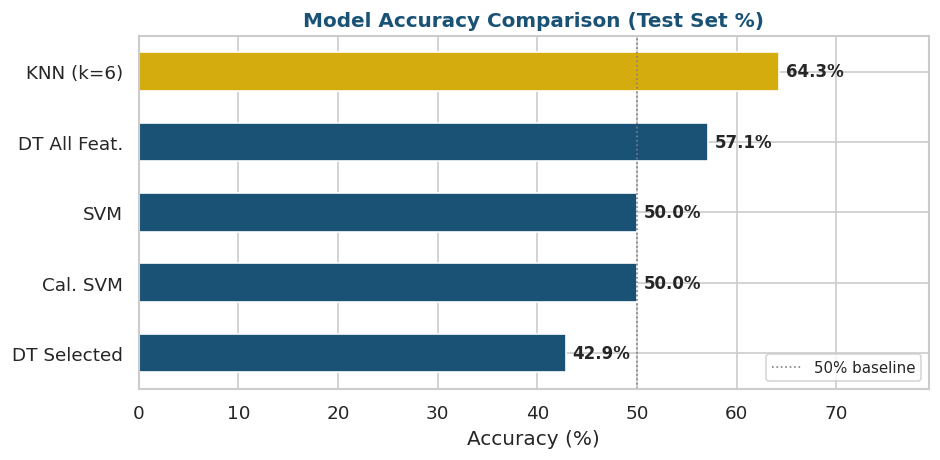

Best model: KNN (k=6) with 64.3% accuracy


In [12]:
model_names  = ['DT Selected', 'Cal. SVM', 'SVM', 'DT All Feat.', 'KNN (k=6)']
model_accs   = [acc_dt_sel, acc_cal, acc_svm, acc_dt_all, acc_knn]

fig, ax = plt.subplots(figsize=(8, 4))
colours = [TEAL if a != max(model_accs) else GOLD for a in model_accs]
bars = ax.barh(model_names, model_accs, color=colours, edgecolor='white', height=0.55)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10, fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison (Test Set %)', fontweight='bold', color=TEAL)
ax.set_xlim(0, max(model_accs) + 15)
ax.axvline(50, color='grey', linestyle=':', linewidth=1, label='50% baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('data/model_comparison.png', bbox_inches='tight')
plt.show()
print('Best model: KNN (k=6) with', f'{acc_knn:.1f}% accuracy')


### 4.2 KNN (k=6) Classification Report & Confusion Matrix

KNN (k=6) Classification Report:
              precision    recall  f1-score   support

         Bad       0.75      0.60      0.67         5
     Neutral       0.00      0.00      0.00         2
        Good       0.60      0.86      0.71         7

    accuracy                           0.64        14
   macro avg       0.45      0.49      0.46        14
weighted avg       0.57      0.64      0.59        14



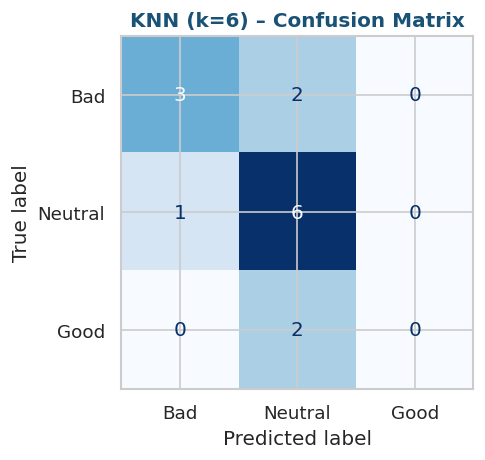

In [13]:
print('KNN (k=6) Classification Report:')
print(classification_report(y_test, y_pred_knn, target_names=class_order,
                            digits=2, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_knn, labels=class_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('KNN (k=6) – Confusion Matrix', fontweight='bold', color=TEAL)
plt.tight_layout()
plt.savefig('data/knn_confusion_matrix.png', bbox_inches='tight')
plt.show()


### 4.3 Feature Importance: All Features vs Screen-Time Only

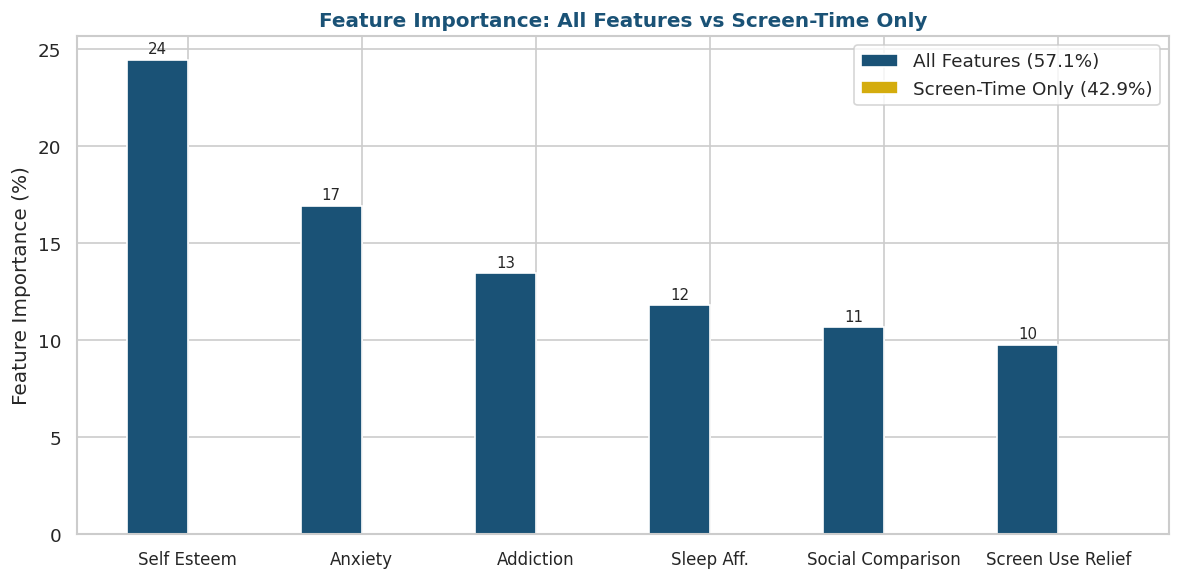

In [14]:
feat_importance_all = dt_all.feature_importances_ * 100
feat_names = feature_cols

# Keep only the 6 most important for the plot (matching the poster)
top6_idx = np.argsort(feat_importance_all)[::-1][:6]
top6_names = [feat_names[i] for i in top6_idx]
top6_vals  = feat_importance_all[top6_idx]

# Screen-time only model feature importances (SM=index 0, VG=index 1)
st_vals = dt_sel.feature_importances_ * 100   # [SM, VG]

# Build combined bar chart
x = np.arange(len(top6_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, top6_vals, width, label='All Features (57.1%)',
               color=TEAL, edgecolor='white')
# Map screen-time vals to the top-6 positions (only SM/VG have values)
st_mapped = np.zeros(len(top6_names))
for i, name in enumerate(top6_names):
    if name == 'Social_Media_Hours': st_mapped[i] = st_vals[0]
    if name == 'Video_Game_Hours':   st_mapped[i] = st_vals[1]

bars2 = ax.bar(x + width/2, st_mapped, width, label='Screen-Time Only (42.9%)',
               color=GOLD, edgecolor='white')

ax.bar_label(bars1, fmt='%.0f', padding=2, fontsize=9)
# Label screen-time bars only where nonzero
for bar, val in zip(bars2, st_mapped):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

short_names = [n.replace('_', ' ').replace('Level','').replace('Affected','Aff.').strip()
               for n in top6_names]
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel('Feature Importance (%)')
ax.set_title('Feature Importance: All Features vs Screen-Time Only',
             fontweight='bold', color=TEAL)
ax.legend()
plt.tight_layout()
plt.savefig('data/feature_importance.png', bbox_inches='tight')
plt.show()


### 4.4 Key Findings Summary

In [15]:
print('=' * 60)
print('  KEY FINDINGS SUMMARY')
print('=' * 60)
print(f'  KNN (k=6) Best Test Accuracy : {acc_knn:.1f}%')
print(f'  Decision Tree (All Features) : {acc_dt_all:.1f}%')
print(f'  SVM / Calibrated SVM         : {acc_svm:.1f}% / {acc_cal:.1f}%')
print(f'  Linear Regression R²         : {r2:.2f}')
print()
print('  ✔ KNN (k=6) was the best model — smallest train/test gap')
print('  ✔ Psychological factors (anxiety, addiction, sleep,')
print('    loneliness) outranked raw screen time as predictors')
print('  ✔ Screen-time only DT accuracy dropped 57.1% → 42.9%')
print('  ✔ Negative R² confirms mood is non-linear w.r.t. features')
print('  ✔ Calibrated SVM provides reliable probability scores')
print('=' * 60)


  KEY FINDINGS SUMMARY
  KNN (k=6) Best Test Accuracy : 64.3%
  Decision Tree (All Features) : 57.1%
  SVM / Calibrated SVM         : 50.0% / 50.0%
  Linear Regression R²         : -0.02

  ✔ KNN (k=6) was the best model — smallest train/test gap
  ✔ Psychological factors (anxiety, addiction, sleep,
    loneliness) outranked raw screen time as predictors
  ✔ Screen-time only DT accuracy dropped 57.1% → 42.9%
  ✔ Negative R² confirms mood is non-linear w.r.t. features
  ✔ Calibrated SVM provides reliable probability scores


## 5. Limitations & Ethics

- **Small sample** (~70 usable rows, mostly UNCC students). Results may not generalise nationally.
- **Self-reported bias**: Respondents may misremember screen time or mood.
- **Class imbalance**: Only 1 'Bad' sample in test set; all models failed to predict this class.
- **Correlation ≠ Causation**: Academic stress may independently explain both screen time and low mood.
- **Privacy**: All responses fully anonymous; no personally identifiable information collected.
- **Not clinical**: For awareness and education only — never use for diagnosis or screening.
